In [38]:
import sys
from pathlib import Path

sys.path.append(str(Path("../src").resolve()))
sys.path.append(str(Path("../utils").resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from data_loader import load_all_data, merge_commodities
from validation import validate_dataset

In [39]:
commodities = load_all_data()

gold = commodities["gold"]
silver = commodities["silver"]
oil = commodities["crude_oil"]
gas = commodities["natural_gas"]
copper = commodities["copper"]

merged = merge_commodities(commodities)

In [42]:
import importlib
import feature_engineering

importlib.reload(feature_engineering)

<module 'feature_engineering' from 'C:\\Users\\ujjwa\\OneDrive\\Documents\\commodity-analytics\\src\\feature_engineering.py'>

In [44]:
from feature_engineering import (
    add_lag_features,
    add_rolling_features,
    add_momentum_features,
    add_rsi,
    add_macd,
    add_bollinger_bands,
    add_volatility_features,
    add_calendar_features,
    add_trend_features
)


featured_data = {}

for name, df in commodities.items():

    df = add_lag_features(df)

    df = add_rolling_features(df)

    df = add_momentum_features(df)

    df = add_rsi(df)

    df = add_macd(df)

    df = add_bollinger_bands(df)

    df = add_volatility_features(df)

    df = add_calendar_features(df)
    
    df=add_trend_features(df)

    featured_data[name] = df

In [45]:
featured_data["gold"].tail()
featured_data["silver"].tail()
featured_data["crude_oil"].tail()

,Adj Close,Close,High,Low,Open,Volume,Lag_1,Lag_7,Lag_14,Lag_30,...,EMA_21,EMA_50,EMA_Crossover,RSI_14,ATR_14,Price_vs_MA30,Price_vs_MA7,Return_1D,Return_5D,Return_20D
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-06,68.550003,68.550003,69.209999,67.820000,68.680000,229909,68.690002,70.339996,84.879997,98.260002,...,76.901250,84.021334,-6.868257,16.302100,3.371429,0.830842,0.984873,-0.002038,-0.009822,-0.263220
2026-07-07,70.440002,70.440002,72.510002,68.580002,68.580002,264072,68.550003,71.919998,80.750000,96.349998,...,76.313864,83.488733,-6.179119,26.557521,3.284286,0.862781,1.015111,0.027571,-0.004382,-0.222001
2026-07-08,73.519997,73.519997,76.080002,71.750000,72.379997,445251,70.440002,69.230003,76.050003,96.599998,...,76.059876,83.097802,-5.078818,43.789868,3.254286,0.909072,1.050221,0.043725,0.057842,-0.194743
2026-07-09,72.080002,72.080002,75.129997,71.419998,74.949997,264009,73.519997,70.750000,76.790001,93.889999,...,75.698069,82.665731,-4.442275,38.822965,3.130714,0.899351,1.026864,-0.019586,0.051035,-0.182766
2026-07-10,71.410004,71.410004,73.160004,70.769997,71.860001,264009,72.080002,69.500000,76.599998,88.680000,...,75.308245,82.224330,-4.013899,37.958238,3.057858,0.897438,1.013380,-0.009295,0.039598,-0.206820


In [46]:
for name, df in featured_data.items():

    featured_data[name] = df.dropna()

In [47]:
gold_features = featured_data["gold"]

corr = gold_features.corr()

corr["Close"].sort_values(ascending=False)

Adj Close         1.000000
Close             1.000000
Low               0.999845
High              0.999726
Open              0.999584
Lag_1             0.999447
EMA_7             0.999395
RollingMean_7     0.999097
RollingMin_7      0.998941
RollingMax_7      0.998746
EMA_21            0.997981
BB_Middle         0.997411
Lag_7             0.996724
RollingMax_30     0.996684
BB_Upper          0.996562
RollingMean_30    0.996213
BB_Lower          0.995768
RollingMin_30     0.995588
EMA_50            0.995055
Lag_14            0.994033
Lag_30            0.987953
RollingStd_30     0.831742
Year              0.827466
ATR_14            0.822671
BB_Width          0.802013
RollingStd_7      0.734499
Volatility_30     0.603577
Volatility_7      0.444668
MACD_Signal       0.370915
MACD              0.334482
EMA_Crossover     0.273517
Momentum_30       0.236635
Price_vs_MA30     0.184942
Return_20D        0.181310
RSI               0.130119
RSI_14            0.130119
Momentum_10       0.122949
R

In [48]:
import importlib
import visualisation

importlib.reload(visualisation)

<module 'visualisation' from 'C:\\Users\\ujjwa\\OneDrive\\Documents\\commodity-analytics\\src\\visualisation.py'>

In [49]:
from visualisation import plot_feature_correlation

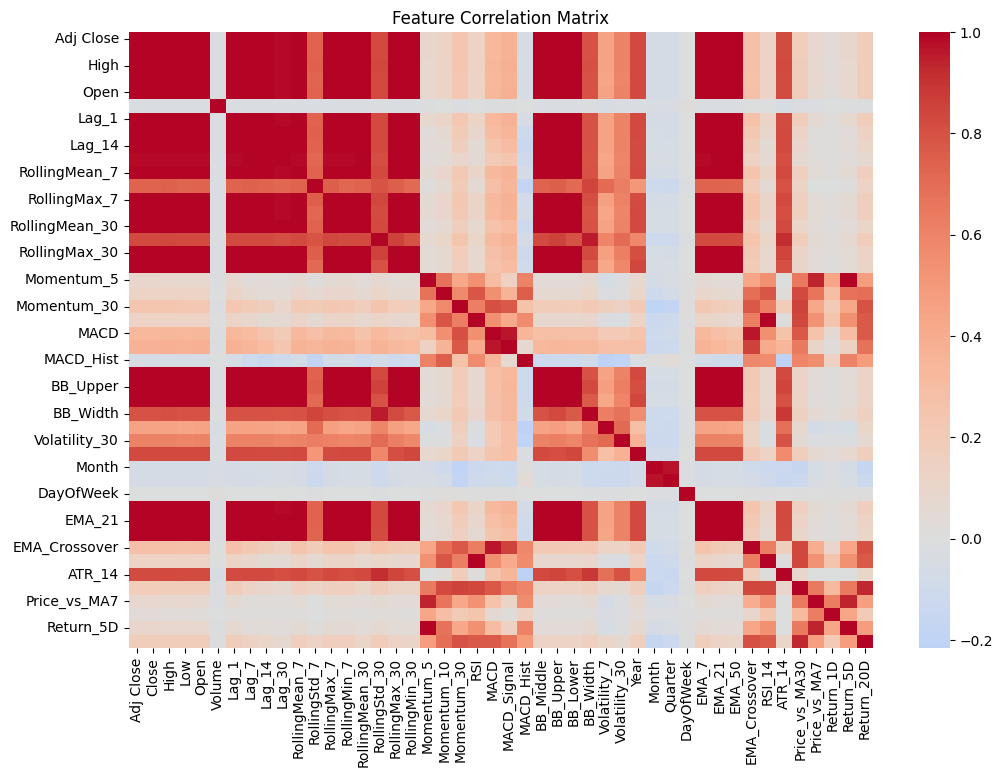

In [50]:
plot_feature_correlation(
    featured_data["gold"]
)

In [51]:
import pickle

with open("../data/processed/features.pkl","wb") as f:
    pickle.dump(featured_data,f)